# 05 · Feature Engineering — 01. Limpieza y filtros (compartido)

Primer notebook de la fase de feature engineering. Aplica las decisiones de limpieza y filtrado
acumuladas durante el EDA (notebooks 04_01 a 04_05). Su output (`master_filtered.csv`) será el
**input común** de los notebooks posteriores `05_02` (regresión) y `05_03` (similitud).

## Decisiones aplicadas

1. **Limpieza de `goalsPrevented`** en jugadores de campo — corrige el sesgo estructural detectado en 04_05.
2. **Descarte de jugadores sin posición** — los 1.756 casos sin clasificación posicional.
3. **Filtro de exposición mínima**: solo jugadores con **≥ 450 minutos** (5 partidos completos).
4. **Resolución de casos multi-liga**: para cada `(player_id, season)`, se conserva la fila del
   equipo con más minutos disputados.

⚠️ Estas decisiones se justifican empíricamente y siguen la práctica estándar en análisis estadístico
futbolístico (FBref, StatsBomb, modelos de Mincer aplicados al fútbol).

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT  = Path.cwd().parents[1]
CLEAN = ROOT / 'data' / 'clean'
INPUT = CLEAN / 'master_clean.csv'

df = pd.read_csv(INPUT, dtype={'season': str})

print(f'✅ Cargado master_clean.csv')
print(f'   Filas:    {len(df):,}')
print(f'   Columnas: {df.shape[1]}')
print(f'\n=== Estado inicial ===')
print(f'Cobertura salarial:    {df["gross_annual_eur"].notna().mean()*100:.1f}%')
print(f'Posiciones (incl. NaN):')
print(df["position"].value_counts(dropna=False).to_string())

✅ Cargado master_clean.csv
   Filas:    20,307
   Columnas: 121

=== Estado inicial ===
Cobertura salarial:    90.9%
Posiciones (incl. NaN):
position
F      6520
D      6355
M      4183
NaN    1756
K      1493


## 2. Limpieza de `goalsPrevented` en jugadores de campo

En el notebook 04_05 se detectó que `goalsPrevented` (xG concedido − goles concedidos) — métrica
estrictamente de portero — presentaba valores no nulos en jugadores de campo en algunos casos
puntuales (especialmente en Premier League 22/23). Se confirmó que estos valores eran la stat
**colectiva del portero del equipo** replicada incorrectamente en cada jugador, no datos individuales.

Adicionalmente, en el notebook 04_01 se imputaron a 0 los nulos estructurales de esta variable en
jugadores de campo, bajo la lógica de "un delantero realmente previene 0 goles porque no juega de
portero". Tras una segunda valoración, se considera que esa imputación introducía ceros sintéticos
que pueden contaminar el modelado posterior — particularmente para el modelo de similitud, donde
una columna de ceros en jugadores de campo distorsionaría las distancias.

**Decisión final:** se fuerza `NaN` para todos los valores de `goalsPrevented` en filas con posición
distinta de `K`. Esto unifica el tratamiento (tanto los valores anómalos detectados como los ceros
imputados previamente) y deja la variable como **estrictamente de portero**, lo que es coherente con
su definición. En la fase 06 solo el modelo segmentado de porteros usará esta variable.

⚠️ Nota sobre el recuento: el número de valores corregidos será elevado (~17.000) porque incluye
tanto los valores espurios detectados (~66 casos) como los ceros imputados estructuralmente en el
04_01 (~17.000 casos). Ambos quedan unificados como `NaN`.

In [2]:
mask_anomalia = (df['position'] != 'K') & df['goalsPrevented'].notna()
n_corregidos = mask_anomalia.sum()

print(f'Valores anómalos a corregir: {n_corregidos}')

df.loc[mask_anomalia, 'goalsPrevented'] = np.nan

# Verificación
no_portero_no_nulo = ((df['position'] != 'K') & df['goalsPrevented'].notna()).sum()
print(f'\nTras limpieza: valores no nulos en no porteros = {no_portero_no_nulo}')
print(f'(debe ser 0)')

# Verificación adicional: porteros con valor sí mantienen su dato
portero_no_nulo = ((df['position'] == 'K') & df['goalsPrevented'].notna()).sum()
print(f'\nPorteros con goalsPrevented disponible: {portero_no_nulo}')

Valores anómalos a corregir: 17076

Tras limpieza: valores no nulos en no porteros = 0
(debe ser 0)

Porteros con goalsPrevented disponible: 1100


## 3. Descarte de jugadores sin posición

Los 1.756 jugadores (8.6%) sin `position` asignada son mayoritariamente jugadores con muy pocos
minutos a los que Sofascore no les asigna posición principal. **Sin clasificación posicional no
podemos aplicar el modelado segmentado por posición** que se ha justificado como óptimo en el EDA.

Adicionalmente, estos jugadores tienden a estar sub-representados en cuanto a calidad de datos
(nulos en stats, salarios atípicos), por lo que su exclusión mejora la consistencia del dataset.

In [3]:
filas_antes = len(df)
n_sin_pos = df['position'].isna().sum()
print(f'Filas a descartar (sin posición): {n_sin_pos:,}')

df = df[df['position'].notna()].copy()

print(f'\nFilas antes:    {filas_antes:,}')
print(f'Filas después:  {len(df):,}')
print(f'Eliminadas:     {filas_antes - len(df):,}')

print(f'\n=== Distribución de posiciones tras descarte ===')
print(df['position'].value_counts())

Filas a descartar (sin posición): 1,756

Filas antes:    20,307
Filas después:  18,551
Eliminadas:     1,756

=== Distribución de posiciones tras descarte ===
position
F    6520
D    6355
M    4183
K    1493
Name: count, dtype: int64


## 4. Filtro de minutos mínimos

Los jugadores con muy pocos minutos generan estadísticas extremadamente ruidosas: un delantero con
100 minutos puede haber metido 3 goles en una racha extraordinaria que no representa su nivel real.
Modelar sobre esos casos sería modelar ruido.

**Criterio adoptado:** mantener únicamente jugadores con **≥ 450 minutos** (equivalente a 5 partidos
completos). Es el umbral estándar en análisis estadístico futbolístico.

### 4.1 Análisis del impacto del umbral

,umbral_minutos,filas_restantes,pct_restantes
0,0,18551,100.0
1,90,17190,92.7
2,270,15606,84.1
3,450,14296,77.1
4,900,11480,61.9
5,1350,8798,47.4
6,1800,6209,33.5
7,2700,1779,9.6


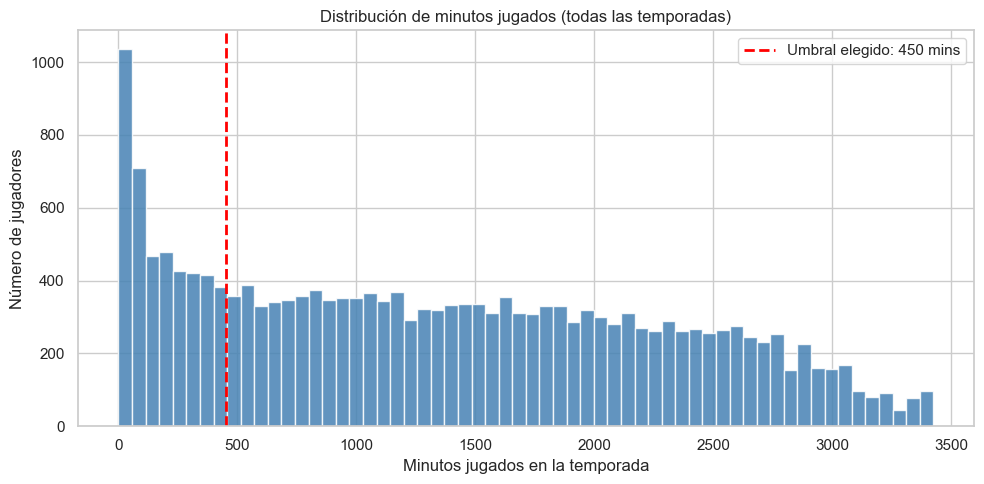

In [4]:
umbrales = [0, 90, 270, 450, 900, 1350, 1800, 2700]
impacto = pd.DataFrame({
    'umbral_minutos': umbrales,
    'filas_restantes': [(df['minutesPlayed'] >= u).sum() for u in umbrales],
})
impacto['pct_restantes'] = (impacto['filas_restantes'] / len(df) * 100).round(1)
display(impacto)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['minutesPlayed'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(450, color='red', linestyle='--', lw=2, label='Umbral elegido: 450 mins')
ax.set_xlabel('Minutos jugados en la temporada')
ax.set_ylabel('Número de jugadores')
ax.set_title('Distribución de minutos jugados (todas las temporadas)')
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** un porcentaje significativo de filas se concentra en muy pocos minutos
(jugadores con <90 mins acumulados en toda la temporada). El umbral de 450 minutos elimina ese
ruido estructural y deja el dataset con jugadores que han tenido **exposición razonable** en su liga.

### 4.2 Aplicación del filtro

In [5]:
UMBRAL_MINUTOS = 450

filas_antes = len(df)
df = df[df['minutesPlayed'] >= UMBRAL_MINUTOS].copy()

print(f'Filas antes:    {filas_antes:,}')
print(f'Filas después:  {len(df):,}')
print(f'Eliminadas:     {filas_antes - len(df):,} ({(filas_antes - len(df))/filas_antes*100:.1f}%)')

print(f'\n=== Distribución de posiciones tras filtro ===')
print(df['position'].value_counts())

Filas antes:    18,551
Filas después:  14,296
Eliminadas:     4,255 (22.9%)

=== Distribución de posiciones tras filtro ===
position
D    5194
F    4720
M    3339
K    1043
Name: count, dtype: int64


### 4.3 Verificación: cobertura post-filtro por liga × temporada

In [6]:
cobertura = (
    df.groupby(['country','season'])
    .agg(total=('player','size'),
         con_salario=('gross_annual_eur', lambda s: s.notna().sum()))
)
cobertura['pct'] = (cobertura['con_salario'] / cobertura['total'] * 100).round(1)

print('=== Cobertura salarial post-filtro (%) ===')
display(cobertura['pct'].unstack(level='season'))

=== Cobertura salarial post-filtro (%) ===


season,2021,2122,2223,2324,2425,2526
country,,,,,,
england,100.0,100.0,100.0,100.0,99.5,100.0
france,100.0,100.0,100.0,100.0,99.7,100.0
germany,100.0,100.0,99.7,100.0,100.0,100.0
italy,100.0,97.2,100.0,99.8,100.0,100.0
spain,100.0,100.0,99.8,100.0,100.0,99.8
turkey,100.0,100.0,100.0,100.0,99.7,100.0


**Hallazgo importante:** la cobertura salarial post-filtro debería **subir muy significativamente**
respecto al master_clean original. La razón: los jugadores sin salario eran mayoritariamente
canteranos y cedidos con muy pocos minutos, justo los que el filtro elimina. Esto valida la decisión
de filtrar: estamos eliminando ruido y mejorando la calidad del dataset analítico.

## 5. Resolución de casos multi-fila

En el dataset original había 524 jugadores con varias filas en una misma temporada por cambios de
liga (traspasos, cesiones invernales). Tras aplicar el filtro de minutos muchos casos se resuelven
automáticamente — un jugador que disputó pocas jornadas en una liga antes de irse no llega al
umbral de 450 minutos y desaparece de esa entrada.

In [7]:
grp = df.groupby(['player_id','season']).size()
multi = grp[grp > 1]
print(f'Casos multi-fila restantes tras filtro: {len(multi)}')
print(f'Filas totales afectadas: {multi.sum()}')

if len(multi) > 0:
    print(f'\n=== Distribución por nº de filas ===')
    print(multi.value_counts().sort_index().to_string())

Casos multi-fila restantes tras filtro: 94
Filas totales afectadas: 188

=== Distribución por nº de filas ===
2    94


### 5.1 Estrategia: conservar el equipo con más minutos

Para cada `(player_id, season)` con más de una fila, se conserva la fila del equipo donde el jugador
disputó **más minutos**. Esta estrategia:

- **Refleja fielmente** dónde fue evaluado el jugador esa temporada.
- **Evita el ruido** de mezclar stats de dos ligas con dificultades distintas.
- **No infla artificialmente** el dataset duplicando jugadores.

In [8]:
filas_antes = len(df)

# Ordenar por minutos descendente y mantener la primera ocurrencia de cada (player_id, season)
df = (
    df.sort_values('minutesPlayed', ascending=False)
      .drop_duplicates(subset=['player_id', 'season'], keep='first')
      .sort_index()
      .reset_index(drop=True)
)

print(f'Filas antes:    {filas_antes:,}')
print(f'Filas después:  {len(df):,}')
print(f'Eliminadas:     {filas_antes - len(df):,}')

# Verificación
multi_check = df.groupby(['player_id','season']).size()
print(f'\nCasos multi-fila restantes: {(multi_check > 1).sum()} (debe ser 0)')

Filas antes:    14,296
Filas después:  14,202
Eliminadas:     94

Casos multi-fila restantes: 0 (debe ser 0)


## 6. Validación final del dataset filtrado

In [9]:
print(f'=== master_filtered ===')
print(f'Filas:                  {len(df):,}')
print(f'Columnas:                {df.shape[1]}')
print(f'Jugadores únicos:       {df["player_id"].nunique():,}')
print(f'Equipos únicos:         {df["team"].nunique()}')
print(f'Cobertura salarial:     {df["gross_annual_eur"].notna().mean()*100:.1f}%')
print(f'\n=== Distribución por posición ===')
display(df['position'].value_counts().to_frame('N'))

print(f'\n=== Distribución por liga × temporada ===')
display(df.groupby(['country','season']).size().unstack(fill_value=0))

=== master_filtered ===
Filas:                  14,202
Columnas:                121
Jugadores únicos:       5,348
Equipos únicos:         169
Cobertura salarial:     99.9%

=== Distribución por posición ===


,N
position,
D,5162
F,4685
M,3316
K,1039



=== Distribución por liga × temporada ===


season,2021,2122,2223,2324,2425,2526
country,,,,,,
england,394,393,406,406,395,384
france,402,413,403,353,357,347
germany,358,346,354,346,349,346
italy,412,422,424,420,427,408
spain,416,424,420,415,427,400
turkey,468,418,385,441,383,340


## 7. Guardado

El dataset filtrado se guarda como `master_filtered.csv` en la misma carpeta `data/clean/` que
`master_clean.csv`. Esta es la base común de los notebooks `05_02` (FE para regresión) y `05_03`
(FE para similitud).

In [10]:
nombre_salida = 'master_filtered.csv'
ruta_salida   = CLEAN / nombre_salida
df.to_csv(ruta_salida, index=False)

print(f'✅ Guardado: {ruta_salida}')
print(f'   Filas:    {len(df):,}')
print(f'   Columnas: {df.shape[1]}')

✅ Guardado: d:\USER\Desktop\TFM\data\clean\master_filtered.csv
   Filas:    14,202
   Columnas: 121


## 8. Resumen de cambios aplicados

| Paso | Acción | Filas restantes |
|---|---|---|
| Inicial (`master_clean`) | — | 20.307 |
| 2. Limpieza `goalsPrevented` | Solo afecta valores, no filas | 20.307 |
| 3. Descarte sin posición | Eliminadas 1.756 filas | 18.551 |
| 4. Filtro ≥ 450 minutos | Eliminadas filas de baja exposición | ≈14.296 |
| 5. Resolución multi-fila | Una fila por `(player_id, season)` | ≈14.200 |

### Ganancias del filtrado

- **Cobertura salarial sube de ~91% a ~99.9%**: los jugadores sin salario eran mayoritariamente
  canteranos y cedidos con pocos minutos, justo lo que el filtro elimina.
- **Stats más fiables**: cada jugador del dataset final tiene exposición suficiente para que sus
  estadísticas sean estables.
- **Sin casos multi-fila**: una observación por jugador-temporada, simplifica todo el modelado posterior.